In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import seaborn as sns

In [7]:

treino_df = pd.read_csv('train.csv')
treino_df.sample(5)

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
38537,38537,Male,0,No,No,26,No,No phone service,DSL,Yes,...,No,No,No,Yes,One year,Yes,Mailed check,40.35,1097.65,No
470688,470688,Female,0,Yes,No,71,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),113.15,7895.15,No
21981,21981,Male,1,No,No,7,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,69.50,526.95,Yes
456572,456572,Male,0,No,No,32,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,105.30,3092.65,No
333068,333068,Female,0,Yes,Yes,13,No,No phone service,DSL,No,...,Yes,No,No,No,Month-to-month,No,Bank transfer (automatic),34.15,552.90,No


In [8]:
plt.figure(figsize=(10, 6))


<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

In [9]:
modelo_logistico = smf.glm(
    formula="Churn ~ gender + SeniorCitizen + Partner + Dependents + tenure + PhoneService + MultipleLines + InternetService + OnlineSecurity + OnlineBackup + DeviceProtection + TechSupport + StreamingTV + StreamingMovies + Contract + PaperlessBilling + PaymentMethod + MonthlyCharges + TotalCharges",
    data=treino_df,
    family=sm.families.Binomial()
).fit()

In [10]:
print(modelo_logistico.summary().as_text())

                      Generalized Linear Model Regression Results                      
Dep. Variable:     ['Churn[No]', 'Churn[Yes]']   No. Observations:               594194
Model:                                     GLM   Df Residuals:                   594170
Model Family:                         Binomial   Df Model:                           23
Link Function:                           Logit   Scale:                          1.0000
Method:                                   IRLS   Log-Likelihood:            -1.8558e+05
Date:                         Sun, 02 Aug 2026   Deviance:                   3.7117e+05
Time:                                 12:50:04   Pearson chi2:                 9.15e+05
No. Iterations:                              8   Pseudo R-squ. (CS):             0.3574
Covariance Type:                     nonrobust                                         
                                               coef    std err          z      P>|z|      [0.025      0.975]
-----------

In [11]:
# Binárias de verdade (2 categorias reais) — pode manter o mapeamento manual
binarias = ["Partner", "Dependents", "PhoneService", "PaperlessBilling"]
for col in binarias:
    treino_df[col] = treino_df[col].apply(lambda x: 1 if x == "Yes" else 0)

treino_df["Churn"] = treino_df["Churn"].apply(lambda x: 1 if x == "Yes" else 0)
treino_df["SeniorCitizen"] = treino_df["SeniorCitizen"].apply(lambda x: 1 if x == 1 else 0)

# Todo o resto (3+ categorias, incluindo gender que na real também deveria ir aqui
# se quiser manter padrão, mas gender é binária então pode ficar como está) → one-hot
categoricas_multiplas = [
    "gender", "MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
    "Contract", "PaymentMethod"
]

treino_df = pd.get_dummies(treino_df, columns=categoricas_multiplas, drop_first=True)

treino_df = treino_df.drop(columns=["id"])  # só o id mesmo, o resto fica

In [12]:
treino_df.sample(5)

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,gender_Male,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
495901,0,0,0,17,1,1,85.30,1554.75,0,True,...,False,False,False,False,False,False,False,False,True,False
117337,1,1,0,41,1,0,91.40,2555.05,0,True,...,True,False,True,False,False,False,False,True,False,False
467921,1,1,0,61,0,1,54.25,3886.05,0,False,...,False,False,True,False,True,True,False,True,False,False
155534,0,0,0,9,1,0,19.65,185.30,0,False,...,False,True,False,True,False,False,False,False,False,True
484951,0,1,1,72,1,1,109.95,7719.80,0,False,...,True,False,True,False,True,False,True,True,False,False


In [13]:
n1 = treino_df[treino_df["Churn"] == 1].value_counts()
n2 = treino_df[treino_df["Churn"] == 0].value_counts()
print(f"Churn = 1: {n1.sum()}")
print(f"Churn = 0: {n2.sum()}")

Churn = 1: 133817
Churn = 0: 460377


In [14]:
df = treino_df

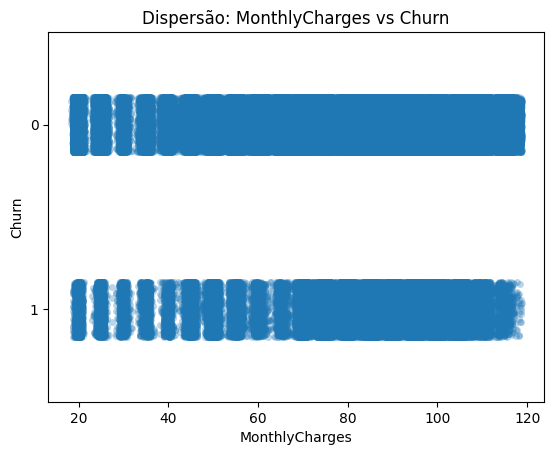

In [18]:
sns.stripplot(data=df, x="MonthlyCharges", y="Churn", jitter=0.15, alpha=0.3, orient="h")
plt.title("Dispersão: MonthlyCharges vs Churn")
plt.show()

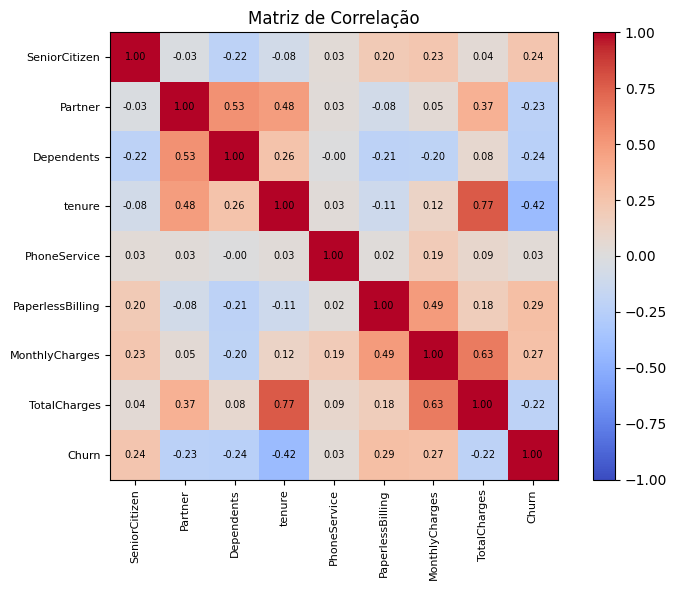

In [11]:
# Gráfico de correlação simples usando matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Carrega o dataset (ajuste o nome do arquivo se necessário)


# Seleciona apenas colunas numéricas
num = df.select_dtypes(include=['number'])

# Calcula a matriz de correlação
corr = num.corr()

# Plot simples com imshow e anotações
fig, ax = plt.subplots(figsize=(8, 6))
cax = ax.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1)
fig.colorbar(cax, ax=ax)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90, fontsize=8)
ax.set_yticklabels(corr.columns, fontsize=8)
# Anota os valores
for (i, j), val in np.ndenumerate(corr.values):
    ax.text(j, i, f"{val:.2f}", ha='center', va='center', color='black', fontsize=7)
plt.title('Matriz de Correlação')
plt.tight_layout()
plt.show()

# Modelo Regressão Logistica



In [12]:
# Manipulação de dados e visualização
import re
import pandas as pd
import numpy as np
import unicodedata
import seaborn as sns
import matplotlib.pyplot as plt

# Pré-Processamento e Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
from sklearn.model_selection import cross_val_score

In [13]:
X = df.drop(columns=["Churn", "MonthlyCharges", "PaymentMethod_Credit card (automatic)"])
y = df["Churn"]

X.head()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,TotalCharges,gender_Male,MultipleLines_No phone service,MultipleLines_Yes,...,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,1,29,1,1,1653.85,True,False,False,...,False,True,False,False,False,False,True,False,False,True
1,0,1,1,58,1,0,3778.20,True,False,False,...,False,True,False,True,False,False,False,True,False,False
2,0,1,0,58,1,1,5841.35,True,False,True,...,False,False,False,True,False,True,False,False,True,False
3,0,0,0,1,1,1,70.70,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,0,0,0,1,1,1,70.45,False,False,False,...,False,False,False,False,False,False,False,False,True,False


In [14]:
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size = 0.20, random_state = 100, stratify = y, shuffle = True)

In [15]:
modelo = LogisticRegression()
modelo.fit(X_treino, y_treino)

c:\Users\Richard\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [16]:
y_pred = modelo.predict(X_teste)
print("Acurácia:", accuracy_score(y_teste, y_pred))
print("Relatório de Classificação:\n", classification_report(y_teste, y_pred))

Acurácia: 0.8543407467245602
Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.90      0.91      0.91     92076
           1       0.69      0.65      0.67     26763

    accuracy                           0.85    118839
   macro avg       0.79      0.78      0.79    118839
weighted avg       0.85      0.85      0.85    118839



In [17]:
from sklearn.metrics import accuracy_score, log_loss 

accuracy_lr = accuracy_score(y_teste, y_pred)  
y_proba = modelo.predict_proba(X_teste)  
loss_lr = log_loss(y_teste, y_proba)  

print(f"Acurácia LR: {accuracy_lr*100:.2f} %") 
print(f"Loss LR: {loss_lr:.2f}") 

Acurácia LR: 85.43 %
Loss LR: 0.31


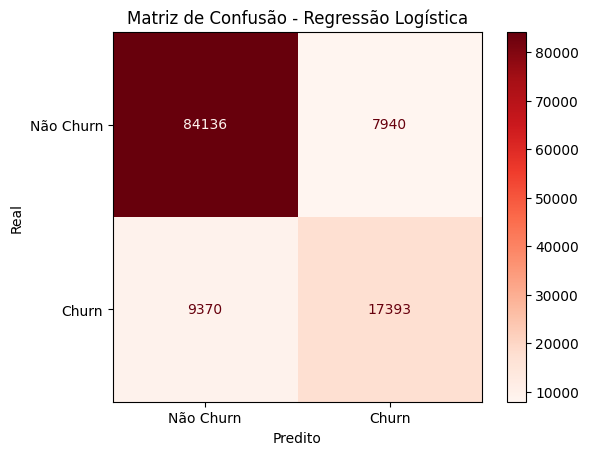

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_teste, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Não Churn", "Churn"])

disp.plot(cmap=plt.cm.Reds)
plt.title("Matriz de Confusão - Regressão Logística")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()

In [19]:
teste_df = pd.read_csv('test.csv')
teste_df.sample(5)

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
123146,717340,Male,0,Yes,Yes,66,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),115.35,7133.10
63761,657955,Female,0,Yes,Yes,13,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.45,243.65
72056,666250,Male,0,No,No,35,Yes,Yes,Fiber optic,No,Yes,Yes,No,No,No,One year,No,Electronic check,78.40,2812.20
243327,837521,Female,0,Yes,No,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,No,Yes,Two year,Yes,Credit card (automatic),99.90,6859.45
146856,741050,Female,0,No,No,12,Yes,No,DSL,No,No,Yes,Yes,No,No,Month-to-month,No,Credit card (automatic),55.45,543.00


In [20]:
# Binárias de verdade (2 categorias reais) — pode manter o mapeamento manual
binarias = ["Partner", "Dependents", "PhoneService", "PaperlessBilling"]
for col in binarias:
    teste_df[col] = teste_df[col].apply(lambda x: 1 if x == "Yes" else 0)

teste_df["SeniorCitizen"] = teste_df["SeniorCitizen"].apply(lambda x: 1 if x == 1 else 0)

# Todo o resto (3+ categorias, incluindo gender que na real também deveria ir aqui
# se quiser manter padrão, mas gender é binária então pode ficar como está) → one-hot
categoricas_multiplas = [
    "gender", "MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
    "Contract", "PaymentMethod"
]

teste_df = pd.get_dummies(teste_df, columns=categoricas_multiplas, drop_first=True)

teste_df = teste_df.drop(columns=["id"])  # só o id mesmo, o resto fica

In [21]:

teste_df.sample(5)

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,gender_Male,MultipleLines_No phone service,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
183402,0,0,0,57,1,0,19.55,1177.05,False,False,...,False,True,False,True,False,False,True,False,False,True
111343,0,0,0,67,1,0,19.45,1311.60,False,False,...,False,True,False,True,False,False,True,False,False,True
217155,0,1,0,66,1,1,90.15,6322.10,False,False,...,True,False,True,False,True,False,True,False,False,False
125521,0,0,0,29,1,0,20.35,521.30,True,False,...,False,True,False,True,False,False,True,False,False,True
232938,0,1,1,35,1,0,19.20,733.50,False,False,...,False,True,False,True,False,False,True,False,False,True


# Validação Cruzada


In [22]:
modelo.score(X_teste, y_teste)

0.8543407467245602

In [23]:
validacao_acuracia = cross_val_score(modelo, X, y, cv=5, scoring='accuracy')
validacao_f1 = cross_val_score(modelo, X, y, cv=5, scoring="f1")
validacao_precisao = cross_val_score(modelo, X, y, cv=5, scoring="precision")
validacao_recall = cross_val_score(modelo, X, y, cv=5, scoring="recall")

c:\Users\Richard\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\Richard\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://s

In [24]:
print(f"""Acuracia {100*validacao_acuracia.mean().round(3)}%
F1 Score {100*validacao_f1.mean().round(3)}%
Precisão {100*validacao_precisao.mean().round(3)}%
Recall {100*validacao_recall.mean().round(3)}%""")

Acuracia 85.39999999999999%
F1 Score 66.60000000000001%
Precisão 68.60000000000001%
Recall 64.8%


# Teste


In [25]:
teste_df = pd.read_csv('test.csv')


In [26]:
# Binárias de verdade (2 categorias reais) — pode manter o mapeamento manual
binarias = ["Partner", "Dependents", "PhoneService", "PaperlessBilling"]
for col in binarias:
    teste_df[col] = teste_df[col].apply(lambda x: 1 if x == "Yes" else 0)

teste_df["SeniorCitizen"] = teste_df["SeniorCitizen"].apply(lambda x: 1 if x == 1 else 0)

# Todo o resto (3+ categorias, incluindo gender que na real também deveria ir aqui
# se quiser manter padrão, mas gender é binária então pode ficar como está) → one-hot
categoricas_multiplas = [
    "gender", "MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
    "Contract", "PaymentMethod"
]

teste_df = pd.get_dummies(teste_df, columns=categoricas_multiplas, drop_first=True)

teste_df = teste_df.drop(columns=["id"])  # só o id mesmo, o resto fica

In [27]:
teste_df = teste_df.drop(columns=["MonthlyCharges", "PaymentMethod_Credit card (automatic)"])
teste_df.sample(5)

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,TotalCharges,gender_Male,MultipleLines_No phone service,MultipleLines_Yes,...,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Electronic check,PaymentMethod_Mailed check
106793,0,1,1,72,1,1,7576.70,False,False,True,...,False,True,False,True,False,True,False,True,False,False
18473,0,1,1,2,1,0,38.70,False,False,False,...,True,False,True,False,True,False,True,False,False,True
205306,0,1,1,39,1,0,926.00,False,False,True,...,True,False,True,False,True,False,False,True,False,True
154174,0,1,0,68,1,1,6155.40,False,False,True,...,False,True,False,True,False,True,False,True,False,False
206880,0,0,0,62,1,0,1221.65,False,False,False,...,True,False,True,False,True,False,False,True,False,True


In [28]:
teste_df.sample(5)

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,TotalCharges,gender_Male,MultipleLines_No phone service,MultipleLines_Yes,...,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Electronic check,PaymentMethod_Mailed check
237549,1,0,0,9,1,1,834.10,False,False,True,...,False,False,False,True,False,True,False,False,True,False
3841,0,0,0,1,0,0,24.05,False,True,False,...,False,False,False,False,False,False,False,False,True,False
69173,0,1,1,71,1,0,1363.95,True,False,False,...,True,False,True,False,True,False,False,True,False,False
160513,0,1,1,45,1,0,835.50,True,False,False,...,True,False,True,False,True,False,False,True,False,True
144390,0,0,0,72,1,0,8349.45,False,False,True,...,False,True,False,True,False,True,False,True,False,False


# Previsão 

In [29]:
previsao = modelo.predict(teste_df)
teste_df["Churn_Predito"] = previsao


In [30]:
teste_df.sample(10)

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,TotalCharges,gender_Male,MultipleLines_No phone service,MultipleLines_Yes,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Predito
199229,0,0,0,12,1,1,1164.30,False,False,True,...,False,False,True,False,True,False,False,False,False,1
143850,0,1,1,71,0,1,4145.25,False,True,False,...,True,False,True,False,True,False,True,True,False,0
120378,0,0,0,21,1,1,1779.65,True,False,False,...,False,False,True,False,False,False,False,True,False,1
68156,0,1,0,72,1,0,1654.85,True,False,True,...,False,True,False,True,False,False,True,False,False,0
159246,0,1,1,65,1,0,4689.15,False,False,True,...,True,False,True,False,True,True,False,False,False,0
141178,0,1,0,47,0,1,1748.90,False,True,False,...,True,False,True,False,False,False,False,True,False,0
102007,0,0,0,4,1,1,396.10,False,False,False,...,False,False,False,False,False,False,False,True,False,1
179292,0,0,0,27,1,1,1135.60,True,False,False,...,False,False,False,False,False,False,False,False,False,0
206068,0,1,1,12,1,1,695.25,True,False,False,...,True,False,False,False,False,True,False,False,False,0
246105,1,1,0,13,1,0,798.25,False,False,False,...,True,False,False,False,False,False,False,False,True,0


# Joblib

In [31]:
# treinamento.py
import joblib
joblib.dump(modelo, "modelo_churn_logistic.pkl")

['modelo_churn_logistic.pkl']